# TAO ADCP Spectral Validation: Mixing Parameterization Comparison

Compares velocity spectra from three TPOSE24 runs against TAO ADCP observations at 0°N, 140°W.

- `oct2012_3mo_dt300_AB3`
- `oct2012_TP6Vel_3month_Ri3`
- `oct2012_TP6Vel_3month_Ri5`

Figures: (1) depth-averaged 1-D PSD, (2) 1-D PSD at selected depths, (3) 2-D PSD(period, depth).

In [1]:
SUBFOLDER = 'mixing_comparison'

RUNS = [
    {'label': 'Ri7',         'color': 'C1', 'ls': '--',
     'path': '/data/SO3/edavenport/tpose24/oct2012_3mo_dt300_AB3/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'},
    {'label': 'Ri3',         'color': 'C2', 'ls': '-.',
     'path': '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri3/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'},
    {'label': 'Ri5',         'color': 'C3', 'ls': ':',
     'path': '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month_Ri5/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'},
]

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import pandas as pd
import os
import warnings
from scipy.signal import welch

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})

os.makedirs(f'TAO_comparison/{SUBFOLDER}', exist_ok=True)

## 1. Load data

In [3]:
TARGET_LON = -140.

def parse_datetime(yyyymmdd, hhmmss):
    d, t = int(yyyymmdd), int(hhmmss)
    yr, mo, dy = d // 10000, (d % 10000) // 100, d % 100
    hh, mm, ss = t // 10000, (t % 10000) // 100, t % 100
    return pd.Timestamp(yr, mo, dy, hh, mm, ss)

def load_run(path):
    ds     = xr.open_dataset(path)
    lons   = ds['prof_lon'].values
    depths = ds['prof_depth'].values
    U      = ds['prof_U'].values.astype(float)
    V      = ds['prof_V'].values.astype(float)
    Ue     = ds['prof_Uestim'].values.astype(float)
    Ve     = ds['prof_Vestim'].values.astype(float)
    ts     = np.array([parse_datetime(d, t) for d, t in
                       zip(ds['prof_YYYYMMDD'].values, ds['prof_HHMMSS'].values)])
    mask = lons == TARGET_LON
    filt = ~np.isnan(Ue[mask]).any(axis=1)
    return depths, ts[mask][filt], U[mask][filt], V[mask][filt], Ue[mask][filt], Ve[mask][filt]

depths, t_obs, U_obs, V_obs, _, _ = load_run(RUNS[0]['path'])
for run in RUNS:
    _, _, _, _, run['U_mod'], run['V_mod'] = load_run(run['path'])

n_prof, n_z = U_obs.shape
dt_h = 1.0
print(f'Profiles: {n_prof}  |  Depths: {n_z} ({depths[0]:.0f}–{depths[-1]:.0f} m)')
print(f'Period: {t_obs[0].date()} – {t_obs[-1].date()}')

Profiles: 2180  |  Depths: 62 (10–315 m)
Period: 2012-10-01 – 2012-12-30


## 2. Compute PSDs

In [4]:
NPERSEG = 1024
FS      = 1.0 / dt_h
f       = np.fft.rfftfreq(NPERSEG, d=dt_h)
T_h     = 1.0 / f[1:]

tidal_marks = {'24 h': (23.93, 0.92, 'black'), 'M2 (12.42 h)': (12.42, 0.92, 'gray')}

def psd_all_depths(arr2d):
    psd = np.full((len(f), arr2d.shape[1]), np.nan)
    for iz in range(arr2d.shape[1]):
        col = arr2d[:, iz]
        if not np.isfinite(col).all():
            continue
        _, p = welch(col - col.mean(), fs=FS, nperseg=NPERSEG, detrend='constant')
        psd[:, iz] = p
    return psd

psd_U_obs = psd_all_depths(U_obs)
psd_V_obs = psd_all_depths(V_obs)

for run in RUNS:
    run['psd_U'] = np.where(np.isnan(psd_U_obs), np.nan, psd_all_depths(run['U_mod']))
    run['psd_V'] = np.where(np.isnan(psd_V_obs), np.nan, psd_all_depths(run['V_mod']))

psd1d_U_obs = np.nanmean(psd_U_obs[1:], axis=1)
psd1d_V_obs = np.nanmean(psd_V_obs[1:], axis=1)
for run in RUNS:
    run['psd1d_U'] = np.nanmean(run['psd_U'][1:], axis=1)
    run['psd1d_V'] = np.nanmean(run['psd_V'][1:], axis=1)

print(f'Frequency resolution: {f[1]:.5f} cph  ({1/f[1]:.0f} h period)')

Frequency resolution: 0.00098 cph  (1024 h period)


## 3. Depth-averaged 1-D spectra

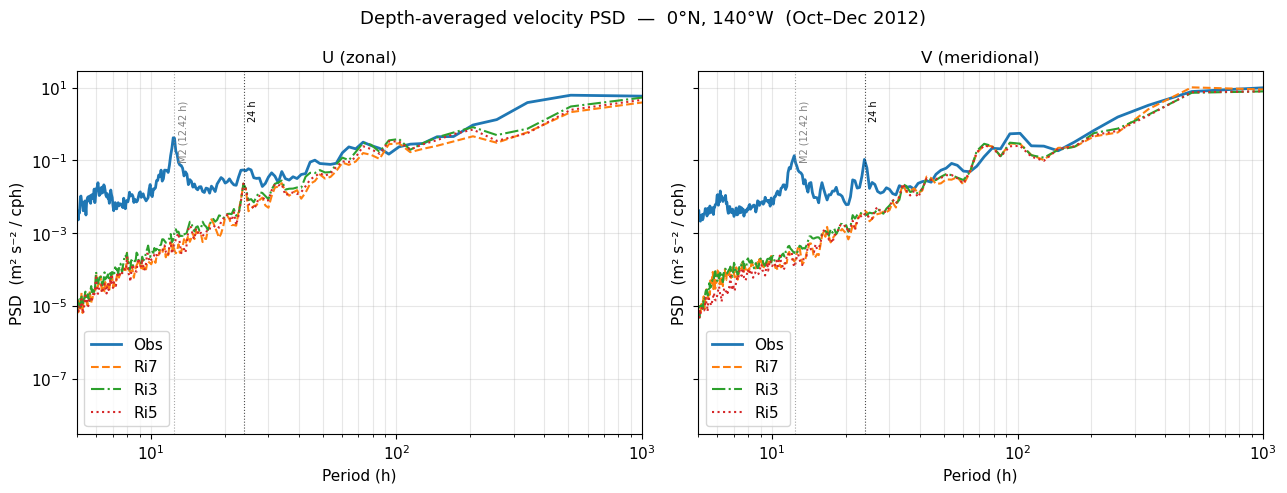

Saved fig_spectra_1d.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Depth-averaged velocity PSD  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

for ax, obs, comp, key in zip(axes,
                               [psd1d_U_obs, psd1d_V_obs],
                               ['U (zonal)', 'V (meridional)'],
                               ['psd1d_U', 'psd1d_V']):
    ax.loglog(T_h, obs, color='C0', lw=2, label='Obs')
    for run in RUNS:
        ax.loglog(T_h, run[key], color=run['color'], lw=1.5, ls=run['ls'], label=run['label'])

    trans = ax.get_xaxis_transform()
    for label, (period, y_ax, color) in tidal_marks.items():
        ax.axvline(period, color=color, lw=0.8, ls=':', alpha=0.7)
        ax.text(period * 1.04, y_ax, label, transform=trans,
                fontsize=7, color=color, rotation=90, ha='left', va='top')

    ax.set_xlabel('Period (h)')
    ax.set_ylabel('PSD  (m² s⁻² / cph)')
    ax.set_title(comp)
    ax.set_xlim([5, 1000])
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.savefig(f'TAO_comparison/{SUBFOLDER}/fig_spectra_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_spectra_1d.png')

## 4. 1-D spectra at selected depths

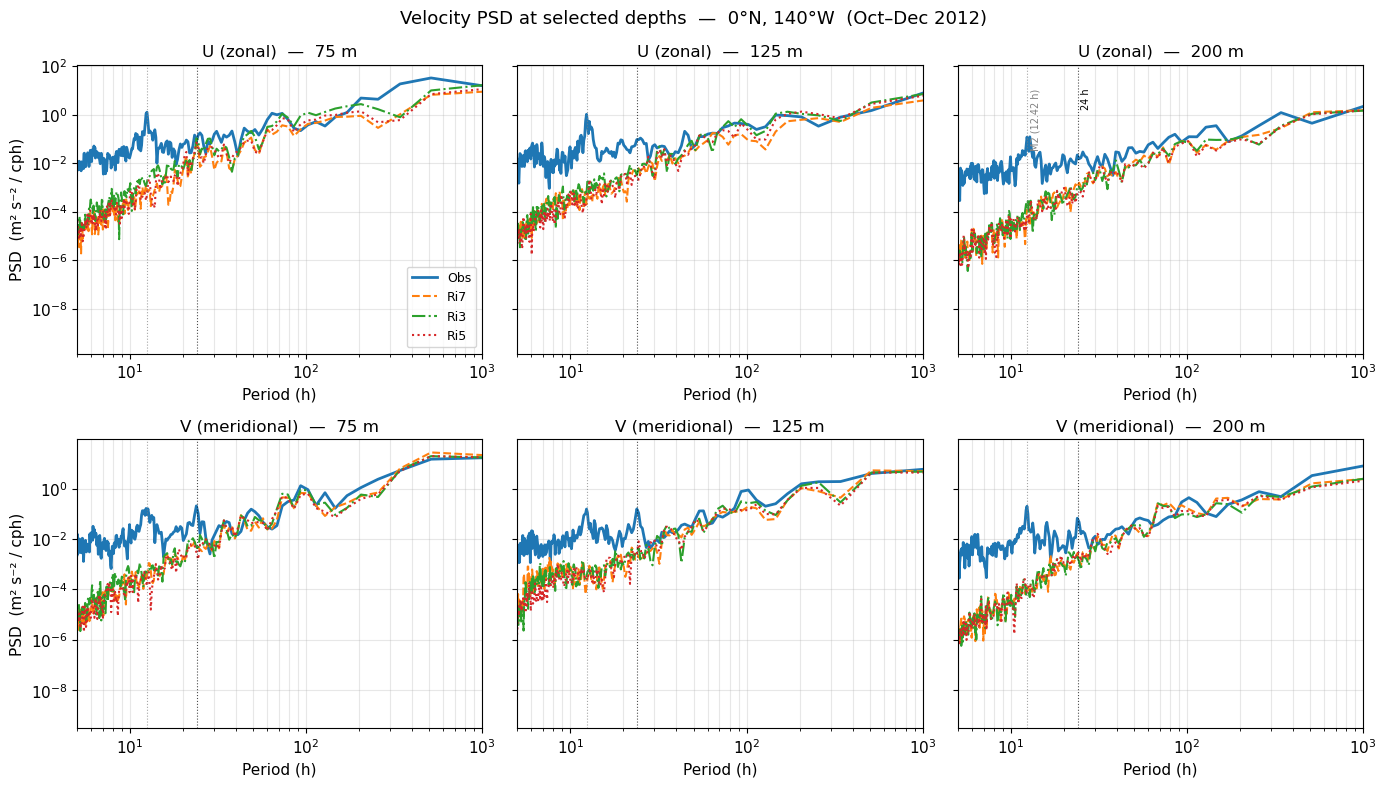

Saved fig_spectra_1d_depths.png


In [6]:
TARGET_DEPTHS = [75, 125, 200]
depth_idxs = [np.argmin(np.abs(depths - d)) for d in TARGET_DEPTHS]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row')
fig.suptitle('Velocity PSD at selected depths  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

for row, (psd_obs_2d, comp, key) in enumerate([
        (psd_U_obs, 'U (zonal)',      'psd_U'),
        (psd_V_obs, 'V (meridional)', 'psd_V')]):
    for col, (iz, td) in enumerate(zip(depth_idxs, TARGET_DEPTHS)):
        ax = axes[row, col]
        ax.loglog(T_h, psd_obs_2d[1:, iz], color='C0', lw=2, label='Obs')
        for run in RUNS:
            ax.loglog(T_h, run[key][1:, iz], color=run['color'], lw=1.5,
                      ls=run['ls'], label=run['label'])

        trans = ax.get_xaxis_transform()
        for lbl, (period, y_ax, color) in tidal_marks.items():
            ax.axvline(period, color=color, lw=0.8, ls=':', alpha=0.7)
            if row == 0 and col == len(TARGET_DEPTHS) - 1:
                ax.text(period * 1.04, y_ax, lbl, transform=trans,
                        fontsize=7, color=color, rotation=90, ha='left', va='top')

        ax.set_xlim([5, 1000])
        ax.set_title(f'{comp}  —  {depths[iz]:.0f} m')
        ax.set_xlabel('Period (h)')
        ax.grid(True, which='both', alpha=0.3)
        if col == 0:
            ax.set_ylabel('PSD  (m² s⁻² / cph)')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig(f'TAO_comparison/{SUBFOLDER}/fig_spectra_1d_depths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_spectra_1d_depths.png')

## 5. 2-D spectra: PSD as a function of frequency and depth

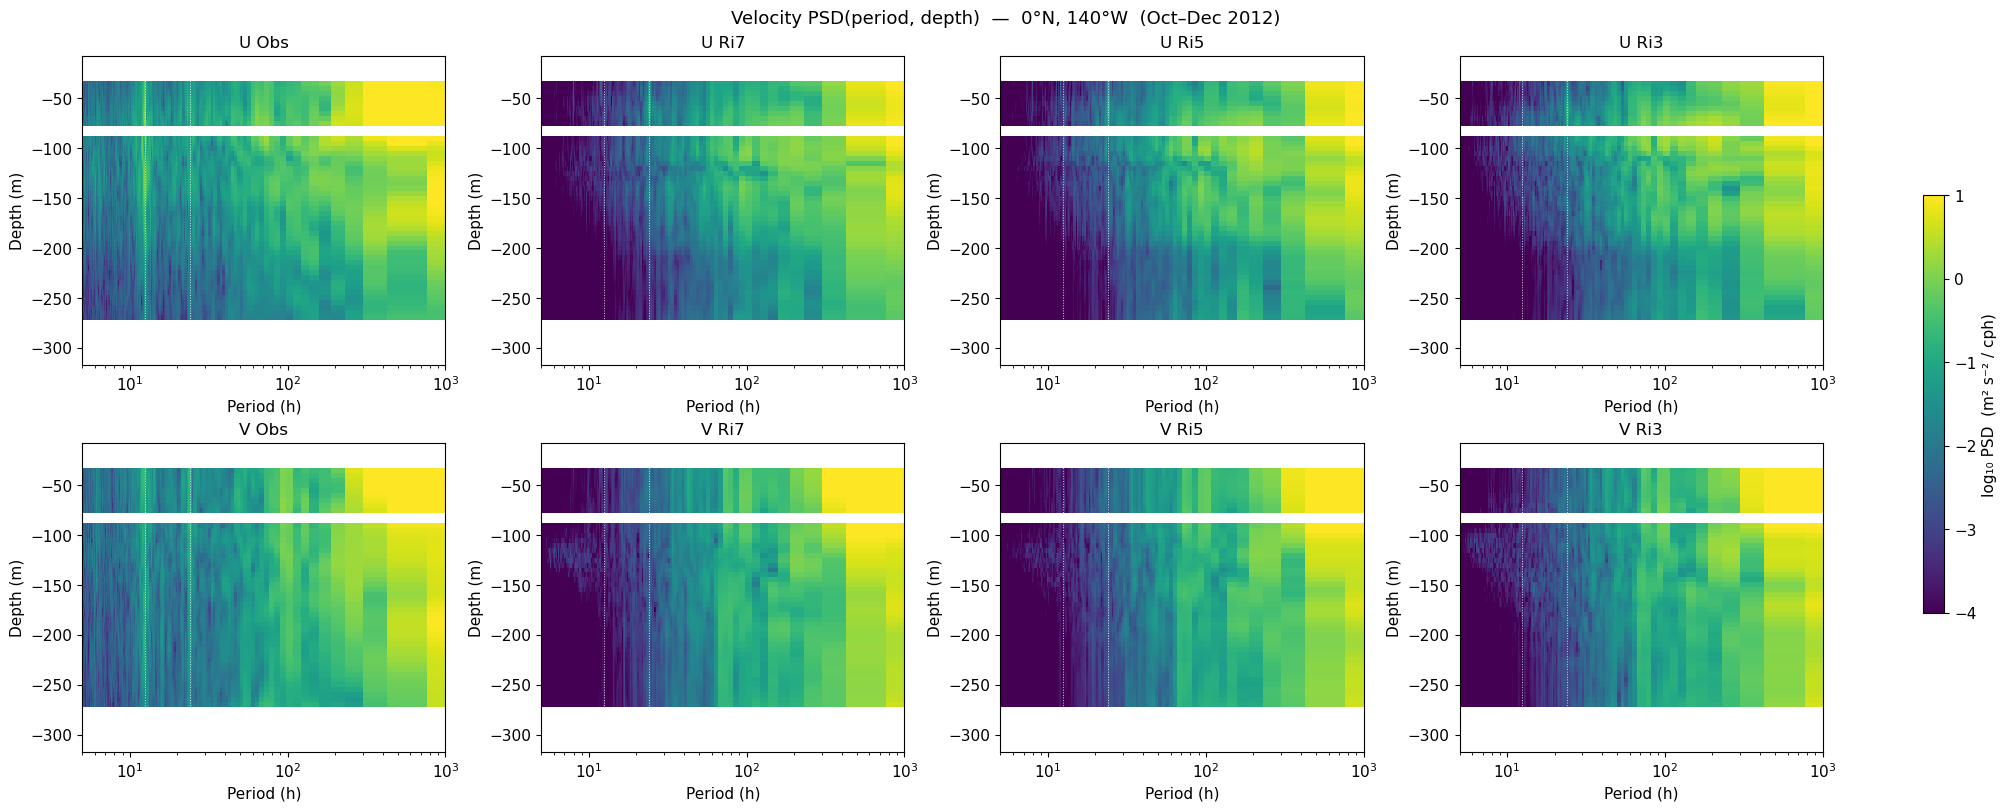

Saved fig_spectra_2d.png


In [7]:
Z = -depths

def log_psd(psd):
    p = psd[1:]
    with np.errstate(divide='ignore'):
        return np.log10(np.where(p > 0, p, np.nan))

logP_U_obs = log_psd(psd_U_obs)
logP_V_obs = log_psd(psd_V_obs)
for run in RUNS:
    run['logP_U'] = log_psd(run['psd_U'])
    run['logP_V'] = log_psd(run['psd_V'])

# Display the 2-D spectra columns in the order Ri7, Ri5, Ri3
RUNS_2D_ORDER = ['Ri7', 'Ri5', 'Ri3']
runs_by_label = {run['label']: run for run in RUNS}
runs_2d = [runs_by_label[label] for label in RUNS_2D_ORDER]

vmin, vmax = -4, 1
kw = dict(cmap='viridis', vmin=vmin, vmax=vmax, shading='auto', rasterized=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 8), constrained_layout=True)
fig.suptitle('Velocity PSD(period, depth)  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

for row, (logP_obs, comp) in enumerate([(logP_U_obs, 'U'), (logP_V_obs, 'V')]):
    im = axes[row, 0].pcolormesh(T_h, Z, logP_obs.T, **kw)
    axes[row, 0].set_title(f'{comp} Obs')
    for col, run in enumerate(runs_2d, start=1):
        lp = run['logP_U'] if comp == 'U' else run['logP_V']
        axes[row, col].pcolormesh(T_h, Z, lp.T, **kw)
        axes[row, col].set_title(f'{comp} {run["label"]}')
    for ax in axes[row]:
        ax.set_xscale('log')
        ax.set_xlim([5, 1000])
        ax.set_xlabel('Period (h)')
        ax.set_ylabel('Depth (m)')
        for period, _, _ in tidal_marks.values():
            ax.axvline(period, color='white', lw=0.7, ls=':', alpha=0.8)

fig.colorbar(im, ax=axes, shrink=0.6, label='log₁₀ PSD  (m² s⁻² / cph)')
plt.savefig(f'TAO_comparison/{SUBFOLDER}/fig_spectra_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_spectra_2d.png')